In [15]:
# 1. Import Libraries and Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

df = pd.read_csv(url)

print(df.head())
print()
print(df.shape)
print()
print(df.columns)
print()
print(df.info())

       country  year         pop continent  lifeExp   gdpPercap
0  Afghanistan  1952   8425333.0      Asia   28.801  779.445314
1  Afghanistan  1957   9240934.0      Asia   30.332  820.853030
2  Afghanistan  1962  10267083.0      Asia   31.997  853.100710
3  Afghanistan  1967  11537966.0      Asia   34.020  836.197138
4  Afghanistan  1972  13079460.0      Asia   36.088  739.981106

(1704, 6)

Index(['country', 'year', 'pop', 'continent', 'lifeExp', 'gdpPercap'], dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   object 
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 80.0+ KB
None


In [16]:
# 2. Rename Columns for data efficiency

df = df.rename(columns={
    "lifeExp": "life_expectancy",
    "pop": "population",
    "gdpPercap": "gdp_per_capita"
})

print(df.head())
print()
print(df.columns)

       country  year  population continent  life_expectancy  gdp_per_capita
0  Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1  Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2  Afghanistan  1962  10267083.0      Asia           31.997      853.100710
3  Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4  Afghanistan  1972  13079460.0      Asia           36.088      739.981106

Index(['country', 'year', 'population', 'continent', 'life_expectancy',
       'gdp_per_capita'],
      dtype='object')


In [22]:
# 3. Check Missing Values and Duplicates

print("Missing values in each column: ")
print(df.isna().sum())
print()
print("Number of duplicate rows: ", df.duplicated().sum())


Missing values in each column: 
country            0
year               0
population         0
continent          0
life_expectancy    0
gdp_per_capita     0
dtype: int64

Number of duplicate rows:  0


In [4]:
# 4. Data Cleaning and Data Type Conversion

df_clean = df.copy()

# Remove exact duplicate rows if any
if df_clean.duplicated().sum() > 0:
    df_clean = df_clean.drop_duplicates()

# Strip extra spaces from text columns
for col in ["country", "continent"]:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Ensure expected data types
df_clean["year"] = df_clean["year"].astype(int)
df_clean["population"] = df_clean["population"].astype(float)
df_clean["life_expectancy"] = df_clean["life_expectancy"].astype(float)
df_clean["gdp_per_capita"] = df_clean["gdp_per_capita"].astype(float)

print(df_clean.dtypes)
print(df_clean.head())

country             object
year                 int64
population         float64
continent           object
life_expectancy    float64
gdp_per_capita     float64
dtype: object
       country  year  population continent  life_expectancy  gdp_per_capita
0  Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1  Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2  Afghanistan  1962  10267083.0      Asia           31.997      853.100710
3  Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4  Afghanistan  1972  13079460.0      Asia           36.088      739.981106


In [26]:
# 5. Missing Value Handling Using Median

dirty_demo = df_clean.head(12).copy()
print()

# Deliberately introduce missing values
dirty_demo.loc[2, "life_expectancy"] = np.nan
dirty_demo.loc[5, "gdp_per_capita"] = np.nan

print(dirty_demo)
print(dirty_demo.isna().sum())
print()

# Fill missing numerical values using median
clean_demo = dirty_demo.copy()
clean_demo["life_expectancy"] = clean_demo["life_expectancy"].fillna(clean_demo["life_expectancy"].median())
clean_demo["gdp_per_capita"] = clean_demo["gdp_per_capita"].fillna(clean_demo["gdp_per_capita"].median())

print(clean_demo.isna().sum())
print(clean_demo)



        country  year  population continent  life_expectancy  gdp_per_capita
0   Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1   Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2   Afghanistan  1962  10267083.0      Asia              NaN      853.100710
3   Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4   Afghanistan  1972  13079460.0      Asia           36.088      739.981106
5   Afghanistan  1977  14880372.0      Asia           38.438             NaN
6   Afghanistan  1982  12881816.0      Asia           39.854      978.011439
7   Afghanistan  1987  13867957.0      Asia           40.822      852.395945
8   Afghanistan  1992  16317921.0      Asia           41.674      649.341395
9   Afghanistan  1997  22227415.0      Asia           41.763      635.341351
10  Afghanistan  2002  25268405.0      Asia           42.129      726.734055
11  Afghanistan  2007  31889923.0      Asia           43.828      974.58033

In [27]:
# 6. Basic Data Analysis

print("Minimum Year:", df_clean["year"].min())
print("Maximum Year:", df_clean["year"].max())

num_countries = df_clean["country"].nunique()

print("Number of Countries:", num_countries)

num_continents = df_clean["continent"].nunique()

print("Number of Continents:", num_continents)

print("Average life expectancy:", df_clean["life_expectancy"].mean())
print("Minimum life expectancy:", df_clean["life_expectancy"].min())
print("Maximum life expectancy:", df_clean["life_expectancy"].max())
print()

print(df_clean.describe())


Minimum Year: 1952
Maximum Year: 2007
Number of Countries: 142
Number of Continents: 5
Average life expectancy: 59.474439366197174
Minimum life expectancy: 23.599
Maximum life expectancy: 82.603

             year    population  life_expectancy  gdp_per_capita
count  1704.00000  1.704000e+03      1704.000000     1704.000000
mean   1979.50000  2.960121e+07        59.474439     7215.327081
std      17.26533  1.061579e+08        12.917107     9857.454543
min    1952.00000  6.001100e+04        23.599000      241.165876
25%    1965.75000  2.793664e+06        48.198000     1202.060309
50%    1979.50000  7.023596e+06        60.712500     3531.846988
75%    1993.25000  1.958522e+07        70.845500     9325.462346
max    2007.00000  1.318683e+09        82.603000   113523.132900


In [28]:
# 7. Grouping Data by Continent

print(df_clean["continent"].value_counts())
print()
continent_summary = df_clean.groupby("continent")[[
    "life_expectancy",
    "gdp_per_capita",
    "population"
]].mean()

print(continent_summary)


continent
Africa      624
Asia        396
Europe      360
Americas    300
Oceania      24
Name: count, dtype: int64

           life_expectancy  gdp_per_capita    population
continent                                               
Africa           48.865330     2193.754578  9.916003e+06
Americas         64.658737     7136.110356  2.450479e+07
Asia             60.064903     7902.150428  7.703872e+07
Europe           71.903686    14469.475533  1.716976e+07
Oceania          74.326208    18621.609223  8.874672e+06


In [30]:
# 8. Filter Data for Latest Year

latest_year = df_clean["year"].max()
latest_df = df_clean[df_clean["year"] == latest_year].copy()

print("Latest year:", latest_year)
print()
print(latest_df.head())
print(latest_df.shape)


Latest year: 2007

        country  year  population continent  life_expectancy  gdp_per_capita
11  Afghanistan  2007  31889923.0      Asia           43.828      974.580338
23      Albania  2007   3600523.0    Europe           76.423     5937.029526
35      Algeria  2007  33333216.0    Africa           72.301     6223.367465
47       Angola  2007  12420476.0    Africa           42.731     4797.231267
59    Argentina  2007  40301927.0  Americas           75.320    12779.379640
(142, 6)


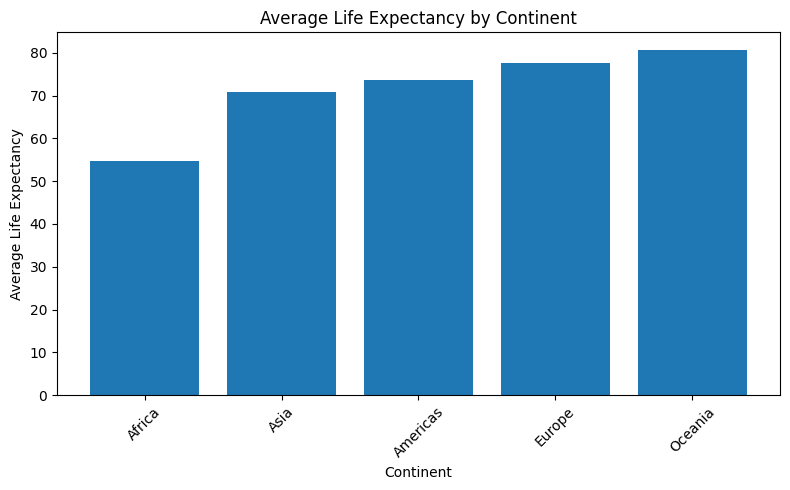

In [33]:
# 9. Bar Chart: Average Life Expectancy by Continent

continent_life = latest_df.groupby("continent")["life_expectancy"].mean().sort_values()

plt.figure(figsize=(8, 5))
plt.bar(continent_life.index, continent_life.values)
plt.title(f"Average Life Expectancy by Continent")
plt.xlabel("Continent")
plt.ylabel("Average Life Expectancy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


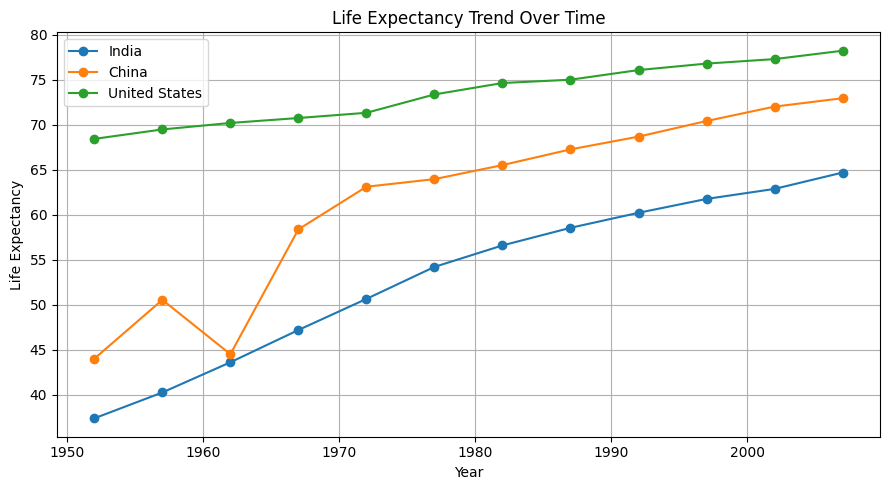

In [34]:
# 10. Line Chart: Life Expectancy of India, China, and USA

selected_countries = ["India", "China", "United States"]
trend_df = df_clean[df_clean["country"].isin(selected_countries)]

plt.figure(figsize=(9, 5))

for country in selected_countries:
    country_df = trend_df[trend_df["country"] == country]
    plt.plot(country_df["year"],
             country_df["life_expectancy"],
             marker="o",
             label=country)

plt.title("Life Expectancy Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

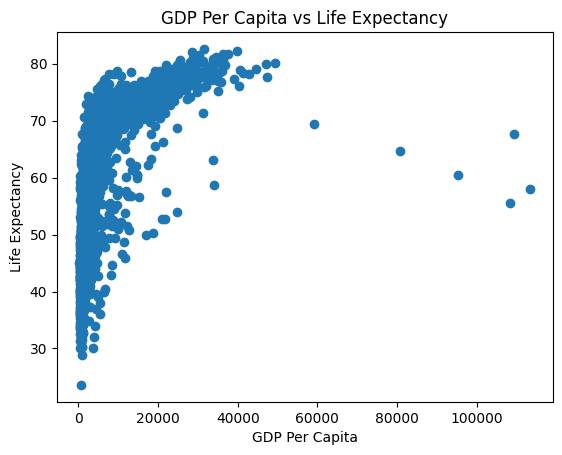

In [13]:
# 11. Scatter Plot: GDP Per Capita vs Life Expectancy

import matplotlib.pyplot as plt

plt.scatter(
    df_clean["gdp_per_capita"],
    df_clean["life_expectancy"]
)

plt.xlabel("GDP Per Capita")
plt.ylabel("Life Expectancy")
plt.title("GDP Per Capita vs Life Expectancy")

plt.show()